# Communal Level EDA & Feature Preparation for Predictive Modeling


This notebook marks the second phase of our exploratory data analysis, shifting focus from the high-level regional overview to the granular communal level. With over 1500 communes, this dataset provides the statistical power required for robust machine learning.


## 1-Setup and data loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

In [3]:
sns.set_style('whitegrid')#setting plot style

In [4]:
df = pd.read_csv("../data/df_final_dataset.csv")

#filtering
territory_type_col= 'Collectivités territoriales'
keyword = 'Commune'
print(f"\nFiltering for rows where the '{territory_type_col}' column contains the keyword: '{keyword}'")

df_communal=df[df[territory_type_col].str.contains(keyword, na=False)].copy()


print(f"Successfully loaded and filtered data. Shape of communal DataFrame: {df_communal.shape}")
df_communal.head()


Filtering for rows where the 'Collectivités territoriales' column contains the keyword: 'Commune'
Successfully loaded and filtered data. Shape of communal DataFrame: (1503, 644)


,Code géographique,Collectivités territoriales,Population légale_ENSEMBLE_TOTAL,Population municipale_ENSEMBLE_TOTAL,Sexe (%)_Masculin_ENSEMBLE_TOTAL,Sexe (%)_Féminin_ENSEMBLE_TOTAL,Âge quinquennal (%)_0-4 ans_ENSEMBLE_TOTAL,Âge quinquennal (%)_5-9 ans_ENSEMBLE_TOTAL,Âge quinquennal (%)_10-14 ans_ENSEMBLE_TOTAL,Âge quinquennal (%)_15-19 ans_ENSEMBLE_TOTAL,...,Mode d’évacuation des déchets ménagers (%)_Bac à ordures de la commune_MENAGES_RURALE,Mode d’évacuation des déchets ménagers (%)_Camion de la commune / Camion privé_MENAGES_RURALE,Mode d’évacuation des déchets ménagers (%)_Dans la nature_MENAGES_RURALE,Mode d’évacuation des déchets ménagers (%)_Autre_MENAGES_RURALE,Combustible de cuisson utilisé (%)_Gaz_MENAGES_RURALE,Combustible de cuisson utilisé (%)_Électricité_MENAGES_RURALE,Combustible de cuisson utilisé (%)_Charbon_MENAGES_RURALE,Combustible de cuisson utilisé (%)_Bois énergie_MENAGES_RURALE,Combustible de cuisson utilisé (%)_Autre_MENAGES_RURALE,Distance moyenne des logements à la route goudronnée (Km)_MENAGES_RURALE
2,01.511.01.0,Commune de Tanger,1275428,1272718,50.6,49.4,8.3,9.2,8.6,7.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,01.511.01.01,Commune d'Assilah,36039,33975,50.2,49.8,7.3,8.6,8.4,7.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,01.511.01.09,Commune de Gueznaia,88676,88673,51.4,48.6,10.9,11.5,9.7,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,01.511.05.19,Commune de Hjar Ennhal,27204,25301,52.2,47.8,11.1,12.0,11.2,7.5,...,46.7,1.4,37.7,14.2,99.2,0.4,0.2,0.0,0.1,0.6
11,01.511.05.07,Commune de Dar Chaoui,4471,4469,53.2,46.8,7.3,8.4,10.2,9.4,...,0.0,0.0,100.0,0.0,83.6,0.1,1.0,14.9,0.3,0.5


## 2- Construct the Target Variable (y) - The Female Economic Vulnerability Index (FEVI)

In [5]:
fevi_indicators = [
    # Core Economic Indicators (Female) ---
    "Taux d'activité des 15 ans et plus (%)_FEMMES_TOTAL",  # Good: Higher is better
    "Taux de chômage (%)_FEMMES_TOTAL",                     # Bad: Higher is worse
    "Statut professionnel des actifs occupés de 15 ans et plus (%)_Aide familial._FEMMES_TOTAL", # Bad: Proxy for informal/unpaid labor
    "Statut professionnel des actifs occupés de 15 ans et plus (%)_Indépendant._FEMMES_TOTAL", # Can be bad: Proxy for informal self-employment

    #  Core Human Capital Indicators 
    "Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_TOTAL", # Bad: Higher is worse
    "Niveau d'études dans l'enseignement général (%)_Aucun niveau d'études._FEMMES_TOTAL", # Bad: Higher is worse
    "Niveau d'études dans l'enseignement général (%)_Supérieur._FEMMES_TOTAL", # Good: Higher is better
    
    # Demographic/Social Context 
    "État matrimonial des 15 ans et plus (%)_Veuf.ve._FEMMES_TOTAL", # Bad: Widowhood is often a driver of economic vulnerability
    "Âge moyen singulier au mariage_FEMMES_TOTAL" # Good: Higher age is often linked to more education/economic stability

    
]


In [7]:
def get_pca_score(df):
    """
    Takes a dataframe, scales it, performs PCA, and returns the first principal component score.
    """
    
    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(imputer.fit_transform(df))
    
    
    pca = PCA(n_components=1)
    principal_components = pca.fit_transform(data_scaled)#transform=shadow position
    
    
    return principal_components.flatten(), pca

In [8]:
#create the dataframe for pca 
df_for_fevi_pca = df_communal[fevi_indicators].copy()

#  Create the score using PCA function
fevi_score, pca_fevi = get_pca_score(df_for_fevi_pca)

In [9]:
y = pd.Series(fevi_score, index=df_communal.index, name="Female_Economic_Vulnerability_Index")

In [10]:
female_illiteracy_col = "Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_TOTAL"
loadings_fevi = pd.Series(pca_fevi.components_[0], index=df_for_fevi_pca.columns)
female_illiteracy_loading = loadings_fevi.get(female_illiteracy_col, 0)

if female_illiteracy_loading < 0:
    print("Flipping sign: Higher score will now correctly mean HIGHER Female Economic Vulnerability.")
    y = -y
else:
    print("Sign is correct: Higher score already means HIGHER Female Economic Vulnerability.")

print("\n--- Target Variable 'y' (FEVI) is complete. ---")
display(y.describe())

Sign is correct: Higher score already means HIGHER Female Economic Vulnerability.

--- Target Variable 'y' (FEVI) is complete. ---


count    1.503000e+03
mean     5.672996e-17
std      1.838126e+00
min     -1.211725e+01
25%     -8.199110e-01
50%      4.443803e-01
75%      1.244095e+00
max      4.853815e+00
Name: Female_Economic_Vulnerability_Index, dtype: float64

## 3- feature selection

In [13]:
X = df_communal.select_dtypes(include=np.number).drop(columns=fevi_indicators)
correlations_with_fevi = X.corrwith(y).abs().sort_values(ascending=False)
#select top n correlated features
top_n = 200
top_structural_predictors = correlations_with_fevi.head(top_n).index
X_top = X[top_structural_predictors].copy()
# prune highly correlated features

def prune_correlated_features(corr_matrix, threshold=0.9):
    """
    Remove features with correlation higher than threshold.
    Returns a list of selected features.
    """
    selected_features = []
    for col in corr_matrix.columns:
        if all(abs(corr_matrix[col][selected_features]) < threshold) if selected_features else True:
            selected_features.append(col)
    return selected_features

final_structural_features = prune_correlated_features(X_top.corr(), threshold=0.9)
X_final = X_top[final_structural_features].copy()

print(f"--- Final Explanatory Feature Matrix 'X_final' with {X_final.shape[1]} features is complete. ---")
display(X_final.head())

C:\Users\fadwa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\fadwa\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


--- Final Explanatory Feature Matrix 'X_final' with 36 features is complete. ---


,Taux d'analphabétisme des 10 ans et plus (%)_FEMMES_TOTAL,Niveau d'études dans l'enseignement général (%)_Secondaire qualifiant._FEMMES_TOTAL,Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_RURALE,Niveau d'études dans l'enseignement général (%)_Supérieur_ENSEMBLE_TOTAL,Taux d'analphabétisme des 10 ans et plus (%)_HOMMES_TOTAL,Niveau d'études dans l'enseignement général (%)_Secondaire collégial._FEMMES_TOTAL,Mode d’évacuation des déchets ménagers (%)_Dans la nature_MENAGES_TOTAL,Mode d’évacuation des déchets ménagers (%)_Bac à ordures de la commune_MENAGES_TOTAL,Mode d’évacuation des eaux usées (%)_Réseau public d'assainissement_MENAGES_TOTAL,Statut d'occupation du logement (%)_Locataire_MENAGES_TOTAL,...,Statut professionnel des actifs occupés de 15 ans et plus (%)_Employeur._HOMMES_URBAIN,Statut d'occupation du logement (%)_Locataire_MENAGES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Salarié du secteur privé_ENSEMBLE_URBAIN,Âge quinquennal (%)_55-59 ans._HOMMES_RURALE,Indicateur conjoncturel de fécondité_ENSEMBLE_RURALE,Âge du logement (%)_50 ans ou plus_MENAGES_RURALE,Âge quinquennal (%)_65-69 ans._HOMMES_URBAIN,Type de logement (%)_Appartement_MENAGES_TOTAL,État matrimonial des 15 ans et plus (%)_Divorcé.e._HOMMES_URBAIN,État matrimonial des 15 ans et plus (%)_Veuf.ve._HOMMES_RURALE
2,20.1,13.8,0.0,12.5,8.9,17.5,0.3,90.1,99.2,43.4,...,3.2,43.4,67.3,0.0,0.00,0.0,2.6,25.6,1.8,0.0
7,22.7,11.4,0.0,12.4,9.3,17.7,1.4,68.9,92.6,19.4,...,3.2,19.4,45.5,0.0,0.00,0.0,4.0,9.2,3.0,0.0
8,17.5,13.2,0.0,11.0,8.6,17.9,0.6,96.3,97.4,35.7,...,2.4,35.7,68.8,0.0,0.00,0.0,1.6,45.3,1.8,0.0
10,27.8,7.5,32.4,3.9,15.2,18.2,37.7,46.7,53.3,11.7,...,0.0,0.0,0.0,2.9,2.36,6.0,0.0,0.2,0.0,0.7
11,40.0,7.0,51.1,3.6,21.2,13.1,80.8,18.3,20.1,3.8,...,1.4,9.7,50.1,3.6,2.43,60.6,4.1,0.0,1.5,0.9


## Descriptive Analysis

- **Statistical Summary of the Final 36 Features (X_final)**

In [17]:
display(X_final.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
Taux d'analphabétisme des 10 ans et plus (%)_FEMMES_TOTAL,1503.0,47.277112,11.801739,4.5,40.500,49.0,55.60,100.00
Niveau d'études dans l'enseignement général (%)_Secondaire qualifiant._FEMMES_TOTAL,1503.0,6.217631,3.592979,0.0,3.900,5.3,7.60,24.50
Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_RURALE,1503.0,49.232069,22.655212,0.0,46.150,56.9,63.70,100.00
Niveau d'études dans l'enseignement général (%)_Supérieur_ENSEMBLE_TOTAL,1503.0,5.231737,3.863017,0.0,2.800,4.0,6.45,47.90
Taux d'analphabétisme des 10 ans et plus (%)_HOMMES_TOTAL,1503.0,26.516101,9.385233,2.0,19.650,27.2,33.00,67.70
Niveau d'études dans l'enseignement général (%)_Secondaire collégial._FEMMES_TOTAL,1503.0,11.381703,3.303701,0.0,9.100,11.3,13.70,21.60
Mode d’évacuation des déchets ménagers (%)_Dans la nature_MENAGES_TOTAL,1503.0,66.894877,36.342186,0.0,36.550,83.6,98.10,100.00
Mode d’évacuation des déchets ménagers (%)_Bac à ordures de la commune_MENAGES_TOTAL,1503.0,19.018230,28.655090,0.0,0.100,1.6,27.95,99.80
Mode d’évacuation des eaux usées (%)_Réseau public d'assainissement_MENAGES_TOTAL,1503.0,21.111178,32.166398,0.0,0.900,3.0,28.50,99.80
Statut d'occupation du logement (%)_Locataire_MENAGES_TOTAL,1503.0,6.404125,9.764435,0.0,0.300,1.7,8.00,65.90


In [18]:
correlations = X_final.corrwith(y).abs().sort_values(ascending=False)
print(correlations.head(5))  # top correlated features

Taux d'analphabétisme des 10 ans et plus (%)_FEMMES_TOTAL                              0.945313
Niveau d'études dans l'enseignement général (%)_Secondaire qualifiant._FEMMES_TOTAL    0.881642
Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_RURALE                             0.859669
Niveau d'études dans l'enseignement général (%)_Supérieur_ENSEMBLE_TOTAL               0.847825
Taux d'analphabétisme des 10 ans et plus (%)_HOMMES_TOTAL                              0.819151
dtype: float64


In [20]:
features_to_plot = [
    "Taux d'analphabétisme des 10 ans et plus (%)_FEMMES_TOTAL",
    "Niveau d'études dans l'enseignement général (%)_Secondaire qualifiant._FEMMES_TOTAL",
    "Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_RURALE",
    "Niveau d'études dans l'enseignement général (%)_Supérieur_ENSEMBLE_TOTAL",
    "Taux d'analphabétisme des 10 ans et plus (%)_HOMMES_TOTAL"
    
]

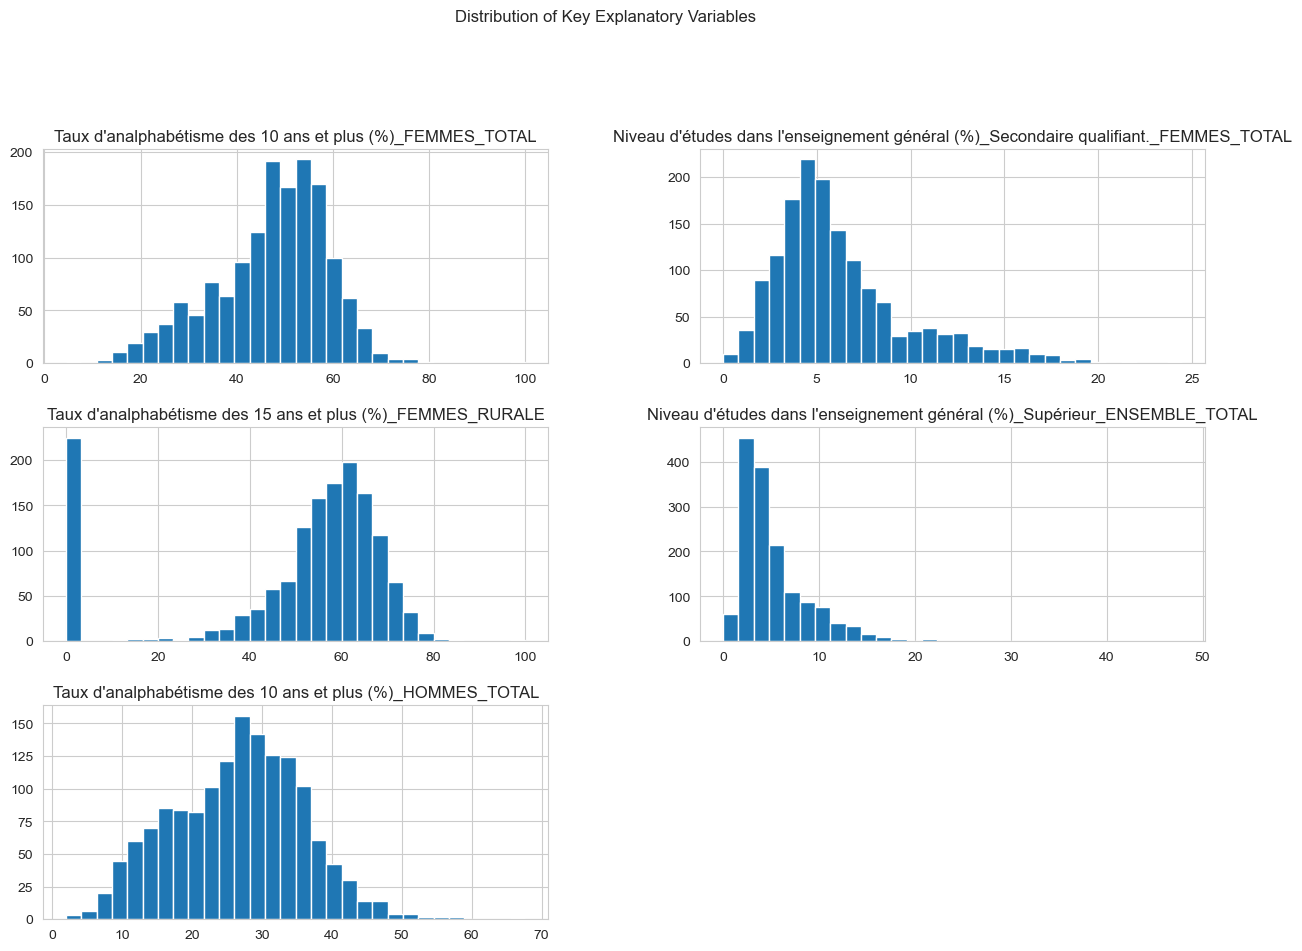

In [22]:
X_final[features_to_plot].hist(bins=30, figsize=(15, 10), layout=(3, 2))
plt.suptitle('Distribution of Key Explanatory Variables', y=1.02)
plt.show()

1. Taux d’analphabétisme des 10 ans et plus (%) – FEMMES_TOTAL
   - Distribution is centered around 40–60%.

   - Suggests that a large portion of communes have very high female illiteracy rates.
  
2. Niveau d’études (%) – Secondaire qualifiant – FEMMES_TOTAL
   -  Most communes cluster around 0–10%.

   - Shows that few women reach secondary qualification.

3. Taux d’analphabétisme des 15 ans et plus (%) – FEMMES_RURALE

   - Similar to total female illiteracy, but distribution is shifted higher.

   - Rural areas clearly have higher illiteracy rates, confirming the urban rural divide
  
4. Niveau d’études (%) – Supérieur – ENSEMBLE_TOTAL

   - Extremely skewed: the majority of communes have close to 0% population with higher education.

   - Only a few communes (probably big cities) reach 20–40%.
  
5. Taux d’analphabétisme des 15 ans et plus (%) – HOMMES_TOTAL

   - Distribution is shifted much lower compared to females.

   - Most communes are around 20–40% male illiteracy.

   - This confirms a strong gender gap in literacy.

## Prepare and Export the Clustering Data

In [24]:
# --- STEP 5: Prepare and Export Data for Clustering ---

# The best data for clustering are the original indicators used to build the FEVI
df_for_clustering = df_communal[fevi_indicators].copy()

# We need to scale this data for clustering algorithms like K-Means
scaler = StandardScaler()
imputer = SimpleImputer(strategy='mean')
data_for_clustering_scaled = scaler.fit_transform(imputer.fit_transform(df_for_clustering))

# Convert to a labeled DataFrame 
df_for_clustering_final = pd.DataFrame(data_for_clustering_scaled, 
                                       index=df_for_clustering.index, 
                                       columns=df_for_clustering.columns)

# Export to CSV
clustering_output_path = '../data/communal_data_for_fevi_clustering.csv'
df_for_clustering_final.to_csv(clustering_output_path)

print(f"Data for clustering successfully prepared and saved to: {clustering_output_path}")


Data for clustering successfully prepared and saved to: ../data/communal_data_for_fevi_clustering.csv


## Export Data for Prediction

In [25]:
target_output_path = '../data/communal_target_fevi.csv'
features_output_path = '../data/communal_features_for_fevi_prediction.csv'

y.to_csv(target_output_path)
X_final.to_csv(features_output_path)

print(f"Target (y) for prediction saved to: {target_output_path}")
print(f"Features (X_final) for prediction saved to: {features_output_path}")

Target (y) for prediction saved to: ../data/communal_target_fevi.csv
Features (X_final) for prediction saved to: ../data/communal_features_for_fevi_prediction.csv
